# 3. Evaluation — Mixture of Experts on UNSW-NB15

Loads trained model and test split, runs inference, reports full evaluation metrics,
and visualizes both **multiclass** and **binary** confusion matrices.


In [1]:
import os, random, pickle, json
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch, torch.nn as nn
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

base_dir   = os.path.join('..')
splits_dir = os.path.join(base_dir, 'data', 'splits')
models_dir = os.path.join(base_dir, 'models')


Device: cuda


## Step 1 — Load artifacts

In [2]:
le     = joblib.load(os.path.join(models_dir, 'label_encoder.pkl'))
scaler = joblib.load(os.path.join(models_dir, 'scaler.pkl'))

with open(os.path.join(models_dir, 'class_mapping.json')) as f:
    class_mapping = json.load(f)

class_names = le.classes_.tolist()
num_classes = len(class_names)
print('Class names:', class_names)

test_df      = pd.read_csv(os.path.join(splits_dir, 'test.csv'))
feature_cols = [c for c in test_df.columns if c != 'label']

X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df['label'].values.astype(np.int64)
num_features = X_test.shape[1]
print(f'Test set: {X_test.shape}  |  Classes: {num_classes}')


Class names: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']
Test set: (381008, 206)  |  Classes: 10


## Step 2 — Rebuild MoE model and load weights

In [3]:
class MoEModel(nn.Module):
    def __init__(self, input_dim, num_classes, dropout_p=0.4):
        super().__init__()
        self.expert1 = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )
        self.expert2 = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )
        self.expert3 = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )
        self.gate    = nn.Sequential(nn.Linear(input_dim, 64), nn.ReLU(), nn.Linear(64, 3))
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        gates = self.softmax(self.gate(x))
        stack = torch.stack([self.expert1(x), self.expert2(x), self.expert3(x)], dim=1)
        return (stack * gates.unsqueeze(-1)).sum(dim=1)

model = MoEModel(num_features, num_classes).to(device)
model.load_state_dict(torch.load(os.path.join(models_dir, 'moe_model.pt'), map_location=device))
model.eval()
print('Model loaded successfully.')


Model loaded successfully.


## Step 3 — Inference on test set

In [4]:
X_t = torch.from_numpy(X_test).to(device)

with torch.no_grad():
    logits    = model(X_t)
    probs     = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred    = torch.argmax(logits, dim=1).cpu().numpy()

y_true = y_test
print('Inference complete. Predictions shape:', y_pred.shape)


Inference complete. Predictions shape: (381008,)


## Step 4 — Multiclass evaluation metrics

In [5]:
acc       = accuracy_score(y_true, y_pred)
prec_mac  = precision_score(y_true, y_pred, average='macro',    zero_division=0)
prec_wt   = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec_mac   = recall_score(y_true, y_pred,    average='macro',    zero_division=0)
rec_wt    = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
f1_mac    = f1_score(y_true, y_pred,        average='macro',    zero_division=0)
f1_wt     = f1_score(y_true, y_pred,        average='weighted', zero_division=0)

print(f'Accuracy          : {acc:.4f}')
print(f'Precision  macro  : {prec_mac:.4f}   weighted: {prec_wt:.4f}')
print(f'Recall     macro  : {rec_mac:.4f}   weighted: {rec_wt:.4f}')
print(f'F1-score   macro  : {f1_mac:.4f}   weighted: {f1_wt:.4f}')

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


Accuracy          : 0.9741
Precision  macro  : 0.5712   weighted: 0.9826
Recall     macro  : 0.6746   weighted: 0.9741
F1-score   macro  : 0.5992   weighted: 0.9770

Classification Report:
                precision    recall  f1-score   support

      Analysis       0.15      0.17      0.16       402
      Backdoor       0.16      0.14      0.15       350
           DoS       0.34      0.76      0.47      2453
      Exploits       0.77      0.56      0.65      6679
       Fuzzers       0.45      0.79      0.57      3637
       Generic       1.00      0.98      0.99     32322
        Normal       1.00      0.99      0.99    332815
Reconnaissance       0.81      0.80      0.80      2098
     Shellcode       0.76      0.86      0.81       226
         Worms       0.29      0.69      0.40        26

      accuracy                           0.97    381008
     macro avg       0.57      0.67      0.60    381008
  weighted avg       0.98      0.97      0.98    381008



## Step 5 — Multiclass confusion matrix

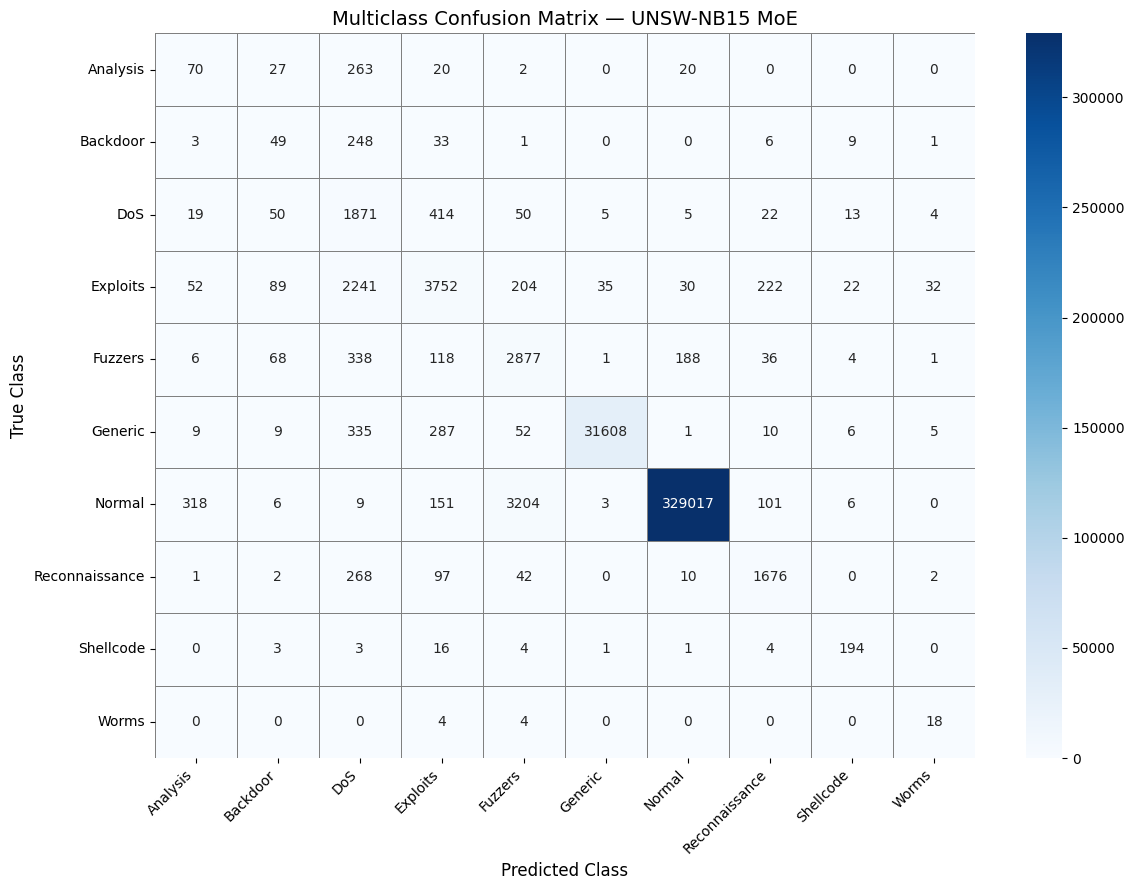

In [6]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            linewidths=0.4, linecolor='grey')
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class',      fontsize=12)
ax.set_title('Multiclass Confusion Matrix — UNSW-NB15 MoE', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 6 — Binary confusion matrix (Normal vs. Attack)

Collapses all attack classes into a single **Attack** label to show detection performance
at the binary intrusion detection level.


True Negatives  (Normal → Normal):  329,017
False Positives (Normal → Attack):  3,798  ← false alarms
False Negatives (Attack → Normal):  255  ← missed attacks
True Positives  (Attack → Attack):  47,938

Binary Accuracy   : 0.9894
Binary Precision  : 0.9266  (of flagged, how many are real attacks)
Binary Recall     : 0.9947  (of all attacks, how many detected)
Binary F1-score   : 0.9594


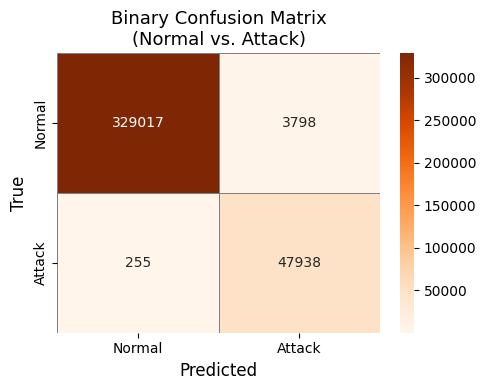

In [7]:
# Identify the integer index of 'Normal' from the LabelEncoder
normal_idx = le.transform(['Normal'])[0]

# Binarize: 0 = Normal, 1 = Attack
y_true_bin = (y_true != normal_idx).astype(int)
y_pred_bin = (y_pred != normal_idx).astype(int)

cm_bin = confusion_matrix(y_true_bin, y_pred_bin)
bin_labels = ['Normal', 'Attack']

tn, fp, fn, tp = cm_bin.ravel()
print(f'True Negatives  (Normal → Normal):  {tn:,}')
print(f'False Positives (Normal → Attack):  {fp:,}  ← false alarms')
print(f'False Negatives (Attack → Normal):  {fn:,}  ← missed attacks')
print(f'True Positives  (Attack → Attack):  {tp:,}')
print()
bin_acc  = accuracy_score(y_true_bin, y_pred_bin)
bin_prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
bin_rec  = recall_score(y_true_bin, y_pred_bin, zero_division=0)
bin_f1   = f1_score(y_true_bin, y_pred_bin, zero_division=0)
print(f'Binary Accuracy   : {bin_acc:.4f}')
print(f'Binary Precision  : {bin_prec:.4f}  (of flagged, how many are real attacks)')
print(f'Binary Recall     : {bin_rec:.4f}  (of all attacks, how many detected)')
print(f'Binary F1-score   : {bin_f1:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Oranges',
            xticklabels=bin_labels, yticklabels=bin_labels,
            linewidths=0.5, linecolor='grey', ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True',      fontsize=12)
ax.set_title('Binary Confusion Matrix\n(Normal vs. Attack)', fontsize=13)
plt.tight_layout()
plt.show()


## Step 7 — Per-class F1-score bar chart

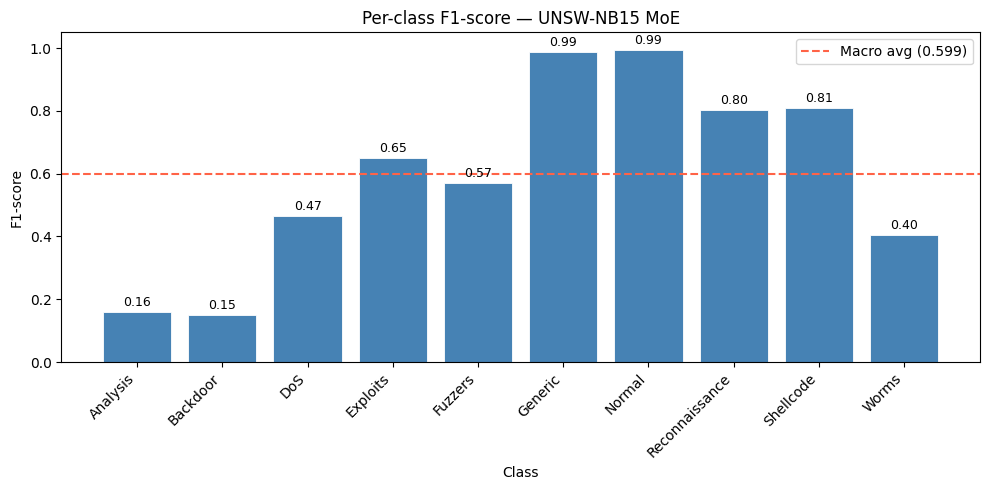

In [8]:
per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_names, per_class_f1, color='steelblue', edgecolor='white', linewidth=0.6)
ax.axhline(f1_mac, color='tomato', linestyle='--', linewidth=1.5, label=f'Macro avg ({f1_mac:.3f})')
ax.set_ylim(0, 1.05)
ax.set_xlabel('Class')
ax.set_ylabel('F1-score')
ax.set_title('Per-class F1-score — UNSW-NB15 MoE')
ax.legend()
for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Step 8 — Training curves (loss, accuracy, LR)

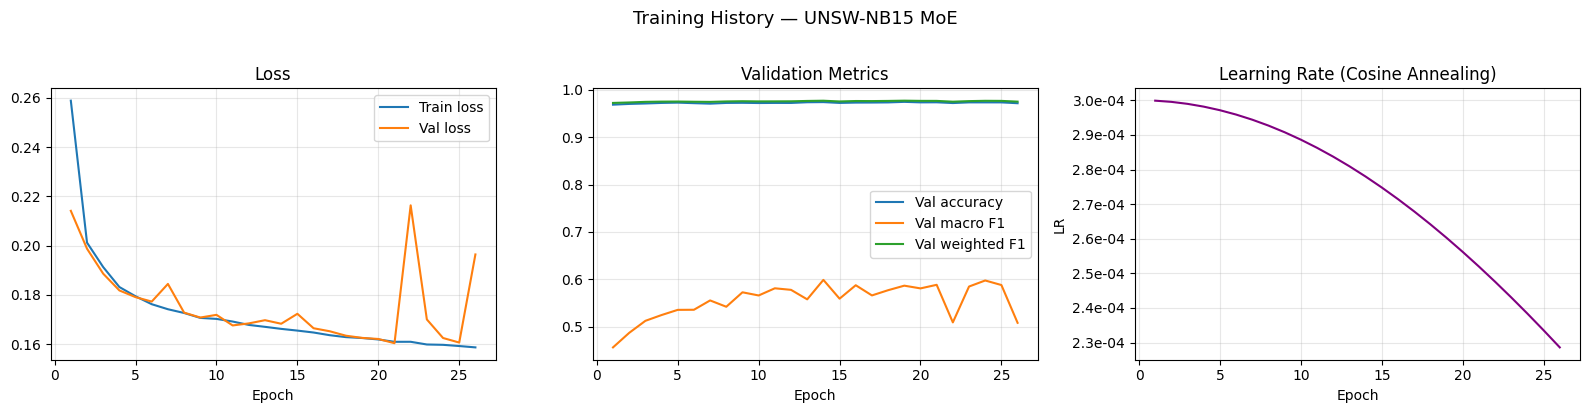

In [9]:
with open(os.path.join(models_dir, 'history.pkl'), 'rb') as f:
    history = pickle.load(f)

epochs   = [h['epoch']          for h in history]
t_loss   = [h['train_loss']     for h in history]
v_loss   = [h['val_loss']       for h in history]
v_acc    = [h['val_acc']        for h in history]
v_f1_mac = [h['val_f1_macro']   for h in history]
v_f1_wt  = [h['val_f1_weighted']for h in history]
lrs      = [h.get('lr', None)   for h in history]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(epochs, t_loss, label='Train loss')
axes[0].plot(epochs, v_loss, label='Val loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy + F1
axes[1].plot(epochs, v_acc,    label='Val accuracy')
axes[1].plot(epochs, v_f1_mac, label='Val macro F1')
axes[1].plot(epochs, v_f1_wt,  label='Val weighted F1')
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
if lrs[0] is not None:
    axes[2].plot(epochs, lrs, color='purple')
    axes[2].set_title('Learning Rate (Cosine Annealing)')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('LR')
    axes[2].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1e'))
    axes[2].grid(True, alpha=0.3)

plt.suptitle('Training History — UNSW-NB15 MoE', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## Step 9 — ROC curves (One-vs-Rest, macro-averaged)

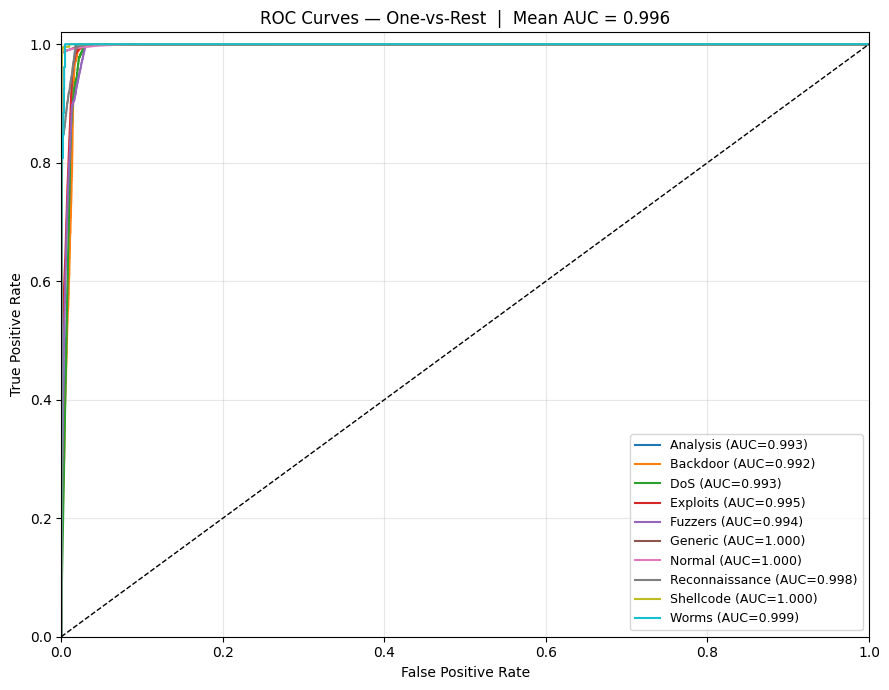

In [10]:
from itertools import cycle

# Binarize ground-truth for OvR
y_bin_ovr = label_binarize(y_true, classes=list(range(num_classes)))

fig, ax = plt.subplots(figsize=(9, 7))
colors = cycle(plt.cm.tab10.colors)

macro_auc_vals = []
for i, (cls, color) in enumerate(zip(class_names, colors)):
    if y_bin_ovr[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_bin_ovr[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    macro_auc_vals.append(roc_auc)
    ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{cls} (AUC={roc_auc:.3f})')

mean_auc = np.mean(macro_auc_vals)
ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curves — One-vs-Rest  |  Mean AUC = {mean_auc:.3f}')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
